# OVERVIEW

This notebook serves as an example of how to use associated src .py files

## *IMPORTS*

Script was created in this project due to importing errors when coding run_scheduled_bot as its own .py file. Due to different working directories, so sys.path.append's got us nowhere. Was retrospectively added to all previous projects, alongside a change in the name of all plotting files since python automatically was choosing the first option (past_market_analysis) due to all previously having the same name.

In [1]:
import sys
from pathlib import Path
if not globals().get("_TRADING_PORTFOLIO_PATHS_READY"):
    _HERE = (
        Path(__file__).resolve().parent
        if "__file__" in globals()
        else Path.cwd().resolve()
    )
    _PROJECTS = (
        "past_market_analysis",
        "technical_analysis",
        "options_pricing",
        "time_series_forecasting",
        "portfolio_construction",
        "ml_fundamentals",
        "ml_trading_signals",
        "risk_management",
        "trading_bot",
    )
    _REPO_ROOT = next(
        (
            directory
            for directory in (_HERE, *_HERE.parents)
            if all((directory / project).is_dir() for project in _PROJECTS)
        ),
        None,
    )
    if _REPO_ROOT is None:
        raise RuntimeError(
            "Could not locate the trading_portfolio repository root."
        )
    _SRC_PATHS = [
        str((_REPO_ROOT / project / "src").resolve())
        for project in _PROJECTS
    ]
    sys.path.extend(path for path in _SRC_PATHS if path not in sys.path)
    _TRADING_PORTFOLIO_PATHS_READY = True


In [2]:
from pipeline import generate_trading_decisions, run_bot, weekly_summary
from broker import get_client, decisions_to_orders, check_order_status
from plotting_trading_bot import plot_run_history


/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## **Analysis**

There is no new signal uncovering or risk methods tested here, but moreso applying both of those projects into an automated trading system. Use the universe from ml_trading_signals alongside the momentum method which showed statistical significance. Also use the final risk method from risk_management, and combine them into a system.

Begin by generating the decisions

In [3]:
#create universe
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "JPM", "JNJ", "XOM", "WMT", "PG", "HD", "DIS", "NFLX", "AMD", "INTC", "CSCO", "ADBE", "CRM"]

decisions, current_exposure, current_drawdown = generate_trading_decisions(tickers)

print(f"Current circuit breaker exposure: {current_exposure:.4f}")
print(f"Current drawdown: {current_drawdown*100:.2f}%\n")
print(decisions.to_string())
print(f"\nSum of relative weights: { decisions['relative_weight'].sum():.4f}")
print(f"Sum of final size: {decisions['final_size'].sum():.4f}")

Rebalanced. New tickers: ['CRM', 'ADBE', 'MSFT', 'NFLX', 'DIS']
Current circuit breaker exposure: 0.3095
Current drawdown: -20.36%

  ticker  momentum_21  base_size  current_price  relative_weight  circuit_breaker_exposure  final_size
0    CRM     0.260307   0.039087     205.429993         0.154520                   0.30947    0.047819
1   ADBE     0.246657   0.038041     272.220001         0.150389                   0.30947    0.046541
2   MSFT     0.232643   0.043090     481.149994         0.170348                   0.30947    0.052718
3   NFLX     0.169415   0.056338      80.139999         0.222720                   0.30947    0.068925
4    DIS     0.119433   0.076398     107.320000         0.302023                   0.30947    0.093467

Sum of relative weights: 1.0000
Sum of final size: 0.3095


Similarly to as stated in risk_management, originally the weights are not scaled to one, and often sum to ~15-25% (0.15-0.25). This is not what we wanted, as this system needs to be tested alone first (and we need to scale by the circuit breaker system), so we scale all weights into 'relative weights' which do sum to 1, and are the weights of each selected ticker relative to the other selected tickers. See that sum is 1, but is being weighted down by the circuit breaker.

The system is run using alpaca and currently is paper trading in order to test quality of the system, and that it actually works.

In [4]:
client = get_client(env_path='../.env')
account = client.get_account()
print(f"Cash: ${account.cash}, Portfolio value: ${account.portfolio_value}")

Cash: $69710.95, Portfolio value: $101305.01


As expected above, the circuit breaker exposure is quite low, so can expect a lot of cash in the portfolio relative to holdings. Orders can be submitted by setting dry_run=False in the below:

In [5]:
orders = decisions_to_orders(decisions, client, dry_run=True)

DRY RUN - Orders set to be placed
 SELL     1 CRM    (target 23, current 24)
 SELL     2 NFLX   (target 87, current 89)
 SELL     2 DIS    (target 88, current 90)


If the code was ran with dry_run=False, the system would submit the above orders to alpaca. We combine this process into one function. 

In [6]:
decisions, orders = run_bot(tickers, submit_orders=False)

--- System run: 2026-08-20 22:47:22.636624 ---

Rebalanced. New tickers: ['CRM', 'ADBE', 'MSFT', 'NFLX', 'DIS']
Circuit breaker exposure: 0.3095
Current drawdown: -0.2036
  ticker  momentum_21  base_size  current_price  relative_weight  circuit_breaker_exposure  final_size
0    CRM     0.260307   0.039087     205.429993         0.154520                   0.30947    0.047819
1   ADBE     0.246657   0.038041     272.220001         0.150389                   0.30947    0.046541
2   MSFT     0.232643   0.043090     481.149994         0.170348                   0.30947    0.052718
3   NFLX     0.169415   0.056338      80.139999         0.222720                   0.30947    0.068925
4    DIS     0.119433   0.076398     107.320000         0.302023                   0.30947    0.093467

Account value: $101,305.01
DRY RUN - Orders set to be placed
 SELL     1 CRM    (target 23, current 24)
 SELL     2 NFLX   (target 87, current 89)
 SELL     2 DIS    (target 88, current 90)
Logged run to ../dat

This also sends an alert to a discord server that only I am a part of, saying "Trading bot — weekly run complete". It also saves the run to a file "../data/bot_log.jsonl", for which analysis can be done in the future.

The aim is to make this automated, which is what caused all the issues with importing. This is done in run_bot_scheduled, where the file aims to 'run_bot'. If it fails, it sends me an alert saying words to the effect of "Trading Failed", and if it works, then the same message as run_bot.

The 'automation' is done through cron on mac, with the following script being ran:
'0 15 * * 1 /path/to/venv/python /path/to/run_bot_scheduled.py >> cron.log 2>&1'
which runs 'run_bot_scheduled' at 3pm every monday.

A weekly summary function is also built in. This is automatically sent to me (through the discord server) when the bot performs a trade.

In [7]:
print(weekly_summary('../data/bot_log.jsonl'))

Portfolio value: $101,305.01 (0.00% since last run)
Exposure: 0.31
Drawdown: -20.4%
Current basket: CRM, ADBE, MSFT, NFLX, DIS


Also have a plotting function which plots the portfolio value, exposure and maximum drawdown of the bot's activities over time.

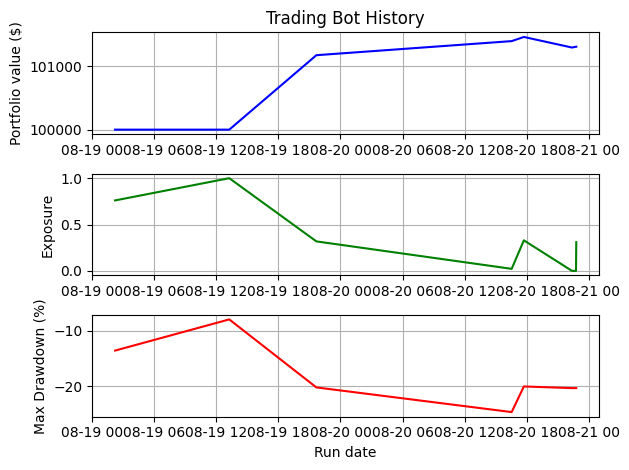

In [8]:
plot_run_history('../data/bot_log.jsonl')

More analysis of the quality to follow when more time has passed.